In [1]:
!https://drive.google.com/drive/folders/1QW6-Bsfch34aLlxwYTOATMwg_VOtoc9K

/bin/bash: line 1: https://drive.google.com/drive/folders/1QW6-Bsfch34aLlxwYTOATMwg_VOtoc9K: No such file or directory


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import zipfile

# Path to the initial zip file
zip_path = "/content/Custom KYC DataSet - Copy.zip"
# Directory where the contents will be extracted
extract_dir = "/content/"

# Unzip the main dataset zip file if it exists
if os.path.exists(zip_path):
    print(f"Extracting main dataset '{zip_path}' to '{extract_dir}'...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Main extraction complete.")
else:
    print(f"Error: Main zip file not found at '{zip_path}'. Please ensure the file is uploaded or correctly mounted.")

# Define the root path after the first extraction
dataset_root_path = "/content/Custom KYC DataSet - Copy"

# Now, extract the nested zip files (train.zip, val.zip) from within the extracted folder
if os.path.exists(dataset_root_path):
    print(f"Checking for nested zip files in '{dataset_root_path}'...")
    train_zip_path = os.path.join(dataset_root_path, 'train.zip')
    val_zip_path = os.path.join(dataset_root_path, 'val.zip')

    if os.path.exists(train_zip_path):
        print(f"Extracting '{train_zip_path}'...")
        with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_root_path) # Extract to the same root, expecting 'train' folder
        print("Train dataset extraction complete.")
    else:
        print(f"Warning: '{train_zip_path}' not found.")

    if os.path.exists(val_zip_path):
        print(f"Extracting '{val_zip_path}'...")
        with zipfile.ZipFile(val_zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_root_path) # Extract to the same root, expecting 'val' folder
        print("Validation dataset extraction complete.")
    else:
        print(f"Warning: '{val_zip_path}' not found.")
else:
    print(f"Error: Extracted root directory '{dataset_root_path}' not found after main extraction.")

# The dataset_path for image_dataset_from_directory should be the root containing 'train' and 'val' folders
dataset_path = dataset_root_path

# Verify the expected 'train' and 'val' subdirectories exist before proceeding
if not os.path.isdir(os.path.join(dataset_path, 'train')) or \
   not os.path.isdir(os.path.join(dataset_path, 'val')):
    print(f"Error: Expected 'train' or 'val' subdirectories not found within '{dataset_path}'.")
    print("Please check the extracted folder structure. Contents of this directory are:")
    print(os.listdir(dataset_path))

# Proceed with loading datasets only if the directory exists and contains expected subfolders
if os.path.isdir(os.path.join(dataset_path, 'train')) and \
   os.path.isdir(os.path.join(dataset_path, 'val')):

    # Note: image_dataset_from_directory expects the path to contain subdirectories for classes or 'train'/'val'
    # Since we have 'train' and 'val' directly under dataset_path, we can point to dataset_path
    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(224, 224),
        batch_size=32
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(224, 224),
        batch_size=32
    )

    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(train_ds, validation_data=val_ds, epochs=5)
else:
    print("Skipping model training due to missing or incorrect dataset directory structure.")


Extracting main dataset '/content/Custom KYC DataSet - Copy.zip' to '/content/'...
Main extraction complete.
Checking for nested zip files in '/content/Custom KYC DataSet - Copy'...
Extracting '/content/Custom KYC DataSet - Copy/train.zip'...
Train dataset extraction complete.
Extracting '/content/Custom KYC DataSet - Copy/val.zip'...
Validation dataset extraction complete.
Found 886 files belonging to 2 classes.
Using 709 files for training.
Found 886 files belonging to 2 classes.
Using 177 files for validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.6891 - loss: 3.1215 - val_accuracy: 0.8136 - val_loss: 0.4925
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.7800 - loss: 0.5152 - val_accuracy: 0.8136 - val_loss: 0.4702
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.7929 - loss: 0.4853 - val_accuracy: 0.8023 - val_loss: 0.4815
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.8262 - loss: 0.4210 - val_accuracy: 0.8079 - val_loss: 0.4986
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.8343 - loss: 0.3793 - val_accuracy: 0.7684 - val_loss: 0.5501


In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the saved model
model_save_path = "./my_kyc_model.keras"
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model loaded successfully!")

# Get class names from the existing val_ds (assuming it's still available)
# If val_ds is not available, you would need to define class_names manually
# based on your dataset's folder structure, e.g., class_names = ['class_a', 'class_b']
class_names = val_ds.class_names
print(f"Class names: {class_names}")

# 2. Prepare a new image for prediction
# --- Option A: Take an image from your existing validation dataset (for demonstration) ---
# for images, labels in val_ds.take(1):
#     sample_image_for_prediction = images[1] # Taking the second image
#     true_label_for_prediction = labels[1]
#     break

# --- Option B: Load your own image file ---
from tensorflow.keras.preprocessing import image
image_path = '/content/sample passport.jpg' # <--- This path has been updated based on your input
img = image.load_img(image_path, target_size=(224, 224)) # Load and resize to model input size
sample_image_for_prediction = image.img_to_array(img)
sample_image_for_prediction = tf.convert_to_tensor(sample_image_for_prediction, dtype=tf.float32)
true_label_for_prediction = None # Since it's a new image, we don't have a true label


# Preprocess the image (rescaling and adding batch dimension)
# The model expects input in batches, so expand dimensions to create a batch of 1 image
input_image_processed = tf.expand_dims(sample_image_for_prediction, 0)

# Ensure the image is scaled similarly to training (model's Rescaling layer will handle 1./255)
# If loading a custom image, ensure its pixel values are 0-255.

# 3. Make a prediction
prediction_scores = loaded_model.predict(input_image_processed)

# 4. Interpret the prediction
# For binary classification with sigmoid output, score < 0.5 is class 0, score >= 0.5 is class 1
predicted_class_index = 0 if prediction_scores[0][0] < 0.5 else 1
predicted_class_name = class_names[predicted_class_index]

print(f"\nPrediction score: {prediction_scores[0][0]:.4f}")
print(f"Predicted class: {predicted_class_name}")
if true_label_for_prediction is not None:
    print(f"True class: {class_names[true_label_for_prediction.numpy()]}")

# Display the image with the prediction
plt.figure(figsize=(4, 4))
plt.imshow(sample_image_for_prediction.numpy().astype("uint8"))
plt.title(f"Predicted: {predicted_class_name} (Score: {prediction_scores[0][0]:.2f})")
plt.axis("off")
plt.show()


Model loaded successfully!
Class names: ['train', 'val']


FileNotFoundError: [Errno 2] No such file or directory: '/content/sample passport.jpg'

In [17]:
import os

print("Contents of /content/ directory:")
for item in os.listdir('/content/'):
    item_path = os.path.join('/content/', item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item}")
    else:
        print(f"  [FILE] {item}")


Contents of /content/ directory:
  [DIR] .config
  [FILE] Custom KYC DataSet - Copy.zip
  [DIR] Custom KYC DataSet - Copy
  [FILE] my_kyc_model.keras
  [DIR] sample_data


In [7]:
import os

# List the contents of the extracted dataset directory
extracted_dataset_root = "/content/Custom KYC DataSet - Copy"

if os.path.exists(extracted_dataset_root):
    print(f"Contents of '{extracted_dataset_root}':")
    for item in os.listdir(extracted_dataset_root):
        item_path = os.path.join(extracted_dataset_root, item)
        if os.path.isdir(item_path):
            print(f"  [DIR] {item}")
            # Optionally, list contents of subdirectories to find image folders
            # For example, uncomment the following to see one level deeper:
            # for sub_item in os.listdir(item_path):
            #     print(f"    - {sub_item}")
        else:
            print(f"  [FILE] {item}")
else:
    print(f"Error: The directory '{extracted_dataset_root}' does not exist. Please ensure the zip file was extracted correctly.")


Contents of '/content/Custom KYC DataSet - Copy':
  [FILE] processed.zip
  [FILE] val.zip
  [FILE] train.zip


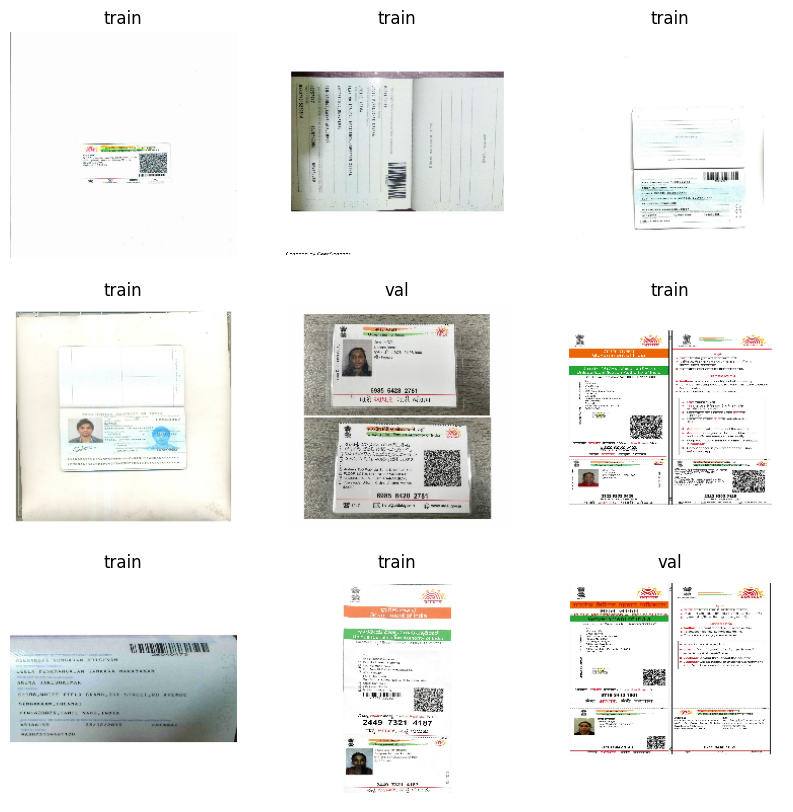

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming train_ds is already defined and loaded from the previous cell
# It's good practice to ensure it exists before trying to display from it
if 'train_ds' in locals() and train_ds is not None:
    plt.figure(figsize=(10, 10))
    for images, labels in train_ds.take(1): # Take one batch of images
        for i in range(9): # Display the first 9 images from the batch
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(train_ds.class_names[labels[i]])
            plt.axis("off")
    plt.show()
else:
    print("Training dataset (train_ds) not found. Please ensure the previous cell ran successfully.")


This code block displays a few sample images from your training dataset, along with their predicted labels. This helps to visually confirm that the images are loaded and processed correctly before being fed into the model.

### 1. Evaluate the Model Performance
Let's see how well your model performs on the validation dataset. This will give you metrics like loss and accuracy.

In [10]:
# Evaluate the model on the validation dataset
print("Evaluating model on validation data...")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


Evaluating model on validation data...
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 819ms/step - accuracy: 0.7486 - loss: 0.5592
Validation Loss: 0.5501
Validation Accuracy: 0.7684


### 2. Make a Prediction on a Sample Image
Now, let's pick an image from the validation set and see what our trained model predicts for it. We'll also display the image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
True label: train
Predicted label: train
Prediction score: 0.3327


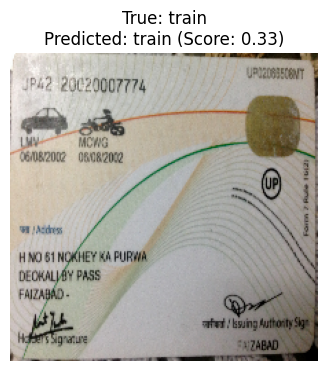

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Take one batch from the validation dataset
for images, labels in val_ds.take(1):
    # Pick the first image from the batch for prediction
    sample_image = images[0]
    sample_label = labels[0]

    # Expand dimensions to create a batch of 1 image
    input_image = tf.expand_dims(sample_image, 0)

    # Make a prediction
    prediction = model.predict(input_image)

    # Get the class names
    class_names = val_ds.class_names

    # The model outputs a single value (sigmoid activation), so interpret it for binary classification
    predicted_class_index = 0 if prediction[0][0] < 0.5 else 1
    predicted_class_name = class_names[predicted_class_index]
    true_class_name = class_names[sample_label.numpy()]

    print(f"True label: {true_class_name}")
    print(f"Predicted label: {predicted_class_name}")
    print(f"Prediction score: {prediction[0][0]:.4f}")

    # Display the image
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_image.numpy().astype("uint8"))
    plt.title(f"True: {true_class_name}\nPredicted: {predicted_class_name} (Score: {prediction[0][0]:.2f})")
    plt.axis("off")
    plt.show()
    break # Only take one image for prediction example


### 3. Save the Trained Model
It's good practice to save your model after training so you can reload it later without needing to retrain it. This saves time and allows for deployment.

### Try the Model with a New Input Image

First, we need to load our saved model. Then, we can pick any image, preprocess it, and ask the model for a prediction.

For demonstration purposes, we'll take another image from the `val_ds`, but you can replace the image loading part with your own image file.

In [15]:
# Define a path to save the model
model_save_path = "./my_kyc_model.keras" # Keras native format

# Save the entire model (architecture, optimizer state, weights)
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

# You can then load it back later with:
# loaded_model = tf.keras.models.load_model(model_save_path)
# print("Model loaded successfully!")


Model saved to ./my_kyc_model.keras
